# 03 · Functional connectivity features $X_f$ (protocol §3.3–3.4)

This notebook turns each participant's resting-state scan into a vector of 4,950 connectivity values.

## Resting-state fMRI and the BOLD signal
- **fMRI** measures the **BOLD** (blood-oxygen-level-dependent) signal. Active neurons draw oxygenated blood, which changes the local MRI signal a few seconds later.
- A **resting-state** scan records the brain while the participant lies still, awake, and does nothing in particular. COBRE's rest scan lasts about 5 minutes, and one 3-D image (a **volume**) is taken every **TR** (repetition time, about 2 s).
- Regions whose slow spontaneous fluctuations rise and fall together are said to be **functionally connected**. Groups of regions that fluctuate together form **networks**, such as the default-mode network. Altered connectivity, both within and between networks, is widely reported in schizophrenia.

## fMRIPrep
fMRIPrep is a standardized, containerized preprocessing pipeline. Among other steps it:
1. estimates head motion and realigns the volumes to one another;
2. corrects slice timing and, where possible, susceptibility distortion;
3. co-registers the BOLD image to the participant's T1w scan;
4. normalizes both to a standard template space, here **MNI152NLin2009cAsym at 2 mm**, so that one atlas fits every participant;
5. writes a **confounds file** with motion parameters, FD, DVARS, white-matter/CSF signals, cosine drift terms and more.

fMRIPrep does *not* denoise the data. Denoising is done in the next step, and it is the protocol's choice, not fMRIPrep's.

## Denoising: confound regression and censoring
Much of the raw BOLD signal is non-neural: head motion, breathing, heartbeat and scanner drift. **Confound regression** fits these nuisance signals to every region's time series and removes them. The primary strategy is nilearn's `load_confounds_strategy("scrubbing")`:

| Component | What it removes |
|---|---|
| **24 motion parameters** | the 6 realignment parameters, their temporal derivatives, and the squares of both. Motion effects are neither instantaneous nor linear. |
| **WM/CSF signals** (+ derivatives, squares) | physiological noise. White matter and cerebrospinal fluid carry little neural signal, so their fluctuations are mostly noise. |
| **Cosine high-pass regressors** | slow scanner drift (fMRIPrep's discrete cosine basis, 128 s cut-off) |
| **Censoring / scrubbing** | volumes with FD > 0.5 mm or standardized DVARS > 1.5, plus leftover segments shorter than 5 volumes |

**Global signal regression (GSR)** would also remove the whole-brain average signal. It reduces motion and physiological artifacts, but it can distort correlations, and the global signal itself differs in schizophrenia. The primary analysis therefore does not use GSR, and "scrubbing + GSR" is a **sensitivity analysis** (notebook 07).

## Atlas and ROI time series
- An **atlas** (or **parcellation**) divides the brain into **regions of interest (ROIs)**. The protocol uses the **Schaefer 2018 atlas with 100 parcels**, each assigned to one of 7 **Yeo networks**: visual (Vis), somatomotor (SomMot), dorsal attention (DorsAttn), salience/ventral attention (SalVentAttn), limbic, frontoparietal control (Cont), and default mode (Default).
- Each ROI's **time series** is the mean denoised signal of its voxels at every retained volume. Each series is then **z-scored** over time.
- Every participant uses the *same* atlas, so feature number $k$ means the same brain connection for everyone.

## From time series to features

**Pearson correlation** between the time series of ROIs $a$ and $b$ (with $T$ retained volumes):

$$r_{ab} = \frac{\sum_t (x_{at}-\bar x_a)(x_{bt}-\bar x_b)}{\sqrt{\sum_t (x_{at}-\bar x_a)^2}\,\sqrt{\sum_t (x_{bt}-\bar x_b)^2}} \in [-1, 1]$$

It is computed with `np.corrcoef`. nilearn's `ConnectivityMeasure` would instead apply a covariance estimator (Ledoit–Wolf shrinkage by default), which gives something different from the plain Pearson correlation the protocol specifies.

**Fisher's z transform**, $\;z = \operatorname{arctanh}(r) = \tfrac12 \ln\frac{1+r}{1-r}$:
- **Why use it:** sample correlations near ±1 vary much less than correlations near 0, so the spread of $r$ depends on its true value. After the transform, $z$ is approximately normal with SD $\approx 1/\sqrt{T-3}$ *regardless of the true correlation*. This is called **variance stabilization**, and it makes features comparable across strengths.
- **Handling the diagonal:** $r = 1$ would give $z = \infty$, so $|r|$ is clipped at $1-10^{-7}$. The diagonal is discarded anyway.

**Vectorization.** The $100 \times 100$ matrix is symmetric ($r_{ab} = r_{ba}$) and its diagonal is always 1. We keep only the **upper triangle excluding the diagonal**:

$$\binom{100}{2} = \frac{100 \times 99}{2} = 4950 \text{ edges per participant}$$

## Temporal SNR (tSNR)
For each voxel, divide the mean of its time series by the standard deviation. Take the median over the brain mask. Low tSNR means noisy data. tSNR is recorded as a data-quality covariate, not used for exclusion.

## Dimensionality: p ≫ n
- **Functional:** 4,950 features for about 146 participants.
- **Structural:** 150 features.

Both blocks have many more features ($p$) than participants ($n$). With $p \gg n$, a linear classifier can always separate the training data perfectly, even when the features are pure noise. That is why the protocol relies on strong **regularization** and **nested cross-validation** (notebooks 04–05), and why it uses **kernels**, which work with an $n \times n$ matrix regardless of $p$.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
def fisher_z(r, eps=1e-7):
    """Fisher r-to-z; |r| is clipped below 1 so perfect correlations stay finite."""
    return np.arctanh(np.clip(r, -1.0 + eps, 1.0 - eps))


def upper_triangle(matrix):
    """Row-major upper triangle of a square matrix, diagonal excluded."""
    rows, cols = np.triu_indices(matrix.shape[0], k=1)
    return matrix[rows, cols]


def edge_table(roi_names, networks=None):
    """One row per edge, in the order produced by ``upper_triangle``."""
    rows, cols = np.triu_indices(len(roi_names), k=1)
    names = np.asarray(roi_names)
    table = pd.DataFrame({
        "feature": [f"fc_{i:03d}_{j:03d}" for i, j in zip(rows, cols)],
        "roi_i": rows, "roi_j": cols,
        "name_i": names[rows], "name_j": names[cols],
    })
    if networks is not None:
        networks = np.asarray(networks)
        table["network_i"] = networks[rows]
        table["network_j"] = networks[cols]
    return table


def roi_network(name):
    """Yeo network from a Schaefer label such as '7Networks_LH_Vis_1'."""
    parts = name.split("_")
    return parts[2] if len(parts) > 3 and parts[0].endswith("Networks") else "NA"

In [3]:
def load_atlas(atlas_cfg):
    """(labels image, ROI names) for the configured atlas (Schaefer 2018 by default)."""
    if atlas_cfg.get("labels_img"):
        labels = pd.read_csv(ROOT / atlas_cfg["labels_tsv"], sep="\t").sort_values("index")
        image, names = str(ROOT / atlas_cfg["labels_img"]), labels["name"].astype(str).tolist()
    else:
        from nilearn.datasets import fetch_atlas_schaefer_2018

        atlas = fetch_atlas_schaefer_2018(
            n_rois=atlas_cfg["n_rois"], yeo_networks=atlas_cfg["yeo_networks"],
            resolution_mm=atlas_cfg["resolution_mm"], data_dir=str(ROOT / "data" / "derivatives" / "atlases"))
        image = atlas.maps
        names = [n.decode() if isinstance(n, bytes) else str(n) for n in atlas.labels]
    names = [n for n in names if n != "Background"]
    if len(names) != atlas_cfg["n_rois"]:
        raise ValueError(f"Atlas has {len(names)} ROI names, expected {atlas_cfg['n_rois']}")
    return image, names


def participant_connectome(bold, atlas_image, denoise_kwargs):
    """Upper-triangle Fisher-z Pearson connectivity and the (volumes, ROIs) shape."""
    from nilearn.interfaces.fmriprep import load_confounds_strategy
    from nilearn.maskers import NiftiLabelsMasker

    confounds, sample_mask = load_confounds_strategy(str(bold), **denoise_kwargs)
    masker = NiftiLabelsMasker(labels_img=atlas_image, standardize="zscore_sample")
    series = masker.fit_transform(str(bold), confounds=confounds, sample_mask=sample_mask)
    if np.any(series.std(axis=0) == 0):
        raise ValueError(f"{bold.name}: an ROI has a constant time series (atlas coverage).")
    # Plain Pearson correlation, as specified; ConnectivityMeasure would apply its covariance estimator.
    r = np.corrcoef(series, rowvar=False)
    return upper_triangle(fisher_z(r)), series.shape


def temporal_snr(bold, mask):
    """Median voxelwise mean/SD over time within the brain mask (before denoising)."""
    from nilearn.masking import apply_mask

    data = apply_mask(str(bold), str(mask))
    mean, sd = data.mean(axis=0), data.std(axis=0)
    keep = sd > 0
    return float(np.median(mean[keep] / sd[keep]))


def extract_functional_features(cfg, strategy="primary"):
    """Connectivity features for every included participant; writes the feature CSVs."""
    func = cfg["functional"]
    denoise_kwargs = func["denoise"][strategy]
    manifest = pd.read_csv(ROOT / cfg["manifest"], dtype={"participant_id": str})
    participants = manifest.loc[manifest["included"] == 1, "participant_id"]
    atlas_image, names = load_atlas(func["atlas"])
    edges = edge_table(names, [roi_network(n) for n in names])

    fmriprep = ROOT / cfg["fmriprep_dir"]
    feature_rows, quality_rows = [], []
    for pid in participants:
        (bold,) = sorted((fmriprep / pid).glob(
            f"**/func/*task-{func['task']}*space-{func['space']}*res-{func['resolution']}"
            "*desc-preproc_bold.nii.gz"))
        vector, shape = participant_connectome(bold, atlas_image, denoise_kwargs)
        if shape[1] != len(names):
            raise ValueError(f"{pid}: {shape[1]} ROI time series, expected {len(names)}")
        feature_rows.append(pd.Series(vector, index=edges["feature"], name=pid))
        mask = Path(str(bold).replace("desc-preproc_bold", "desc-brain_mask"))
        quality_rows.append({"participant_id": pid, "tsnr_median": temporal_snr(bold, mask)})

    features = pd.DataFrame(feature_rows).rename_axis("participant_id").reset_index()
    quality = pd.DataFrame(quality_rows)
    out = ROOT / cfg["features_dir"]
    out.mkdir(parents=True, exist_ok=True)
    features.to_csv(out / f"functional_features_{strategy}.csv", index=False)
    edges.to_csv(out / "functional_edges.csv", index=False)
    quality.to_csv(out / f"functional_qc_{strategy}.csv", index=False)
    return features, edges, quality

## Demo 1: from ROI time series to a connectivity vector
- **Data:** 12 synthetic ROIs, in 3 "networks" of 4.
- **How the signals are built:** each ROI's signal is its network's shared fluctuation plus independent noise.
- **What you should see:** regions correlate within their network but not across networks, giving block structure on the diagonal of the matrix.

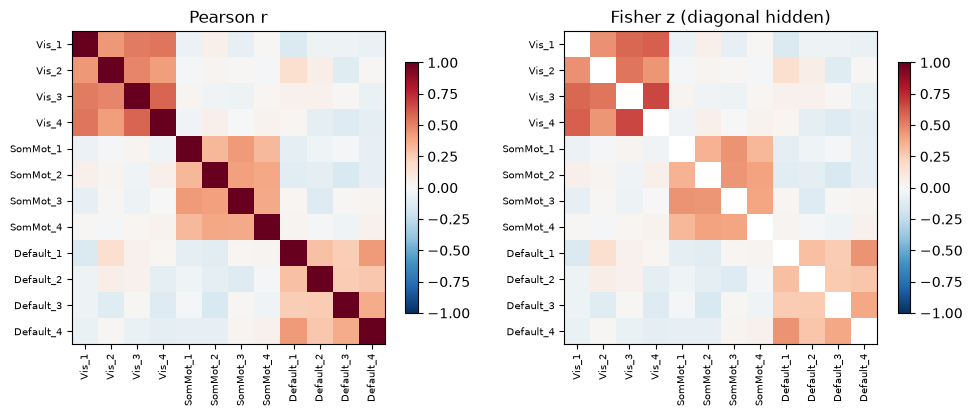

12 ROIs -> 66 edges; with 100 ROIs -> 4950 edges


,feature,roi_i,roi_j,name_i,name_j,network_i,network_j,value
0,fc_000_001,0,1,7Networks_LH_Vis_1,7Networks_LH_Vis_2,Vis,Vis,0.460
1,fc_000_002,0,2,7Networks_LH_Vis_1,7Networks_LH_Vis_3,Vis,Vis,0.574
2,fc_000_003,0,3,7Networks_LH_Vis_1,7Networks_LH_Vis_4,Vis,Vis,0.594
3,fc_000_004,0,4,7Networks_LH_Vis_1,7Networks_LH_SomMot_1,Vis,SomMot,-0.060
4,fc_000_005,0,5,7Networks_LH_Vis_1,7Networks_LH_SomMot_2,Vis,SomMot,0.052
5,fc_000_006,0,6,7Networks_LH_Vis_1,7Networks_LH_SomMot_3,Vis,SomMot,-0.080


In [4]:
rng = np.random.default_rng(0)
T, networks = 150, ["Vis", "SomMot", "Default"]
names = [f"7Networks_LH_{net}_{k}" for net in networks for k in range(1, 5)]
latent = rng.normal(size=(T, len(networks)))
series = np.column_stack([0.8 * latent[:, i // 4] + rng.normal(size=T) for i in range(len(names))])
series = (series - series.mean(axis=0)) / series.std(axis=0)

r = np.corrcoef(series, rowvar=False)
z = fisher_z(r)
z_plot = z.copy()
np.fill_diagonal(z_plot, np.nan)
labels = [n.split("_", 2)[2] for n in names]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, matrix, title, limit in [(axes[0], r, "Pearson r", 1.0), (axes[1], z_plot, "Fisher z (diagonal hidden)", 1.0)]:
    image = ax.imshow(matrix, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_xticks(range(len(names)), labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(names)), labels, fontsize=7)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

vector = upper_triangle(z)
edges = edge_table(names, [roi_network(n) for n in names])
print(f"{len(names)} ROIs -> {len(vector)} edges; with 100 ROIs -> {100 * 99 // 2} edges")
display(edges.assign(value=vector.round(3)).head(6))

## Demo 2: Fisher's z stabilizes the variance of correlations
- **Setup:** we simulate 2,000 correlations between two 150-volume series at several true correlation strengths $\rho$.
- **What changes:** the spread (SD) of $r$ shrinks as $\rho$ grows.
- **What doesn't:** the spread of $z$ stays close to $1/\sqrt{T-3}$ throughout.

true ρ = 0.1:  SD of r = 0.082   SD of z = 0.083   theory 1/√(T−3) = 0.082
true ρ = 0.5:  SD of r = 0.062   SD of z = 0.083   theory 1/√(T−3) = 0.082


true ρ = 0.8:  SD of r = 0.030   SD of z = 0.084   theory 1/√(T−3) = 0.082


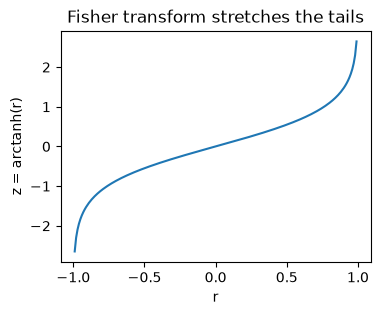

In [5]:
for rho in (0.1, 0.5, 0.8):
    samples = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=(2000, T))
    rs = np.array([np.corrcoef(s, rowvar=False)[0, 1] for s in samples])
    print(f"true ρ = {rho}:  SD of r = {rs.std():.3f}   SD of z = {np.arctanh(rs).std():.3f}   "
          f"theory 1/√(T−3) = {1 / np.sqrt(T - 3):.3f}")

grid = np.linspace(-0.99, 0.99, 200)
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(grid, np.arctanh(grid))
ax.set_xlabel("r")
ax.set_ylabel("z = arctanh(r)")
ax.set_title("Fisher transform stretches the tails")
plt.show()

## Demo 3: why head motion must be removed before computing connectivity
**The artifact.** A sudden head movement changes the signal in *every* region at the same moment.

**What it does to connectivity.** Those shared jumps inflate correlations everywhere, including between networks that are truly unrelated.

**The fix.** Censoring the affected volumes removes the artifact before correlations are computed.

In [6]:
bad = rng.choice(T, size=8, replace=False)
spiky = series.copy()
spiky[bad] += rng.normal(6, 1, size=(len(bad), 1))      # the same jump in every ROI = motion-like artifact
keep = np.setdiff1d(np.arange(T), bad)
network_of = np.array([roi_network(n) for n in names])
between = network_of[:, None] != network_of[None, :]


def mean_between_network_r(x):
    return np.corrcoef(x, rowvar=False)[between].mean()


print(f"clean data:                 mean between-network r = {mean_between_network_r(series):.3f}")
print(f"with 8 motion spikes:       mean between-network r = {mean_between_network_r(spiky):.3f}")
print(f"spike volumes censored:     mean between-network r = {mean_between_network_r(spiky[keep]):.3f}")

clean data:                 mean between-network r = -0.026
with 8 motion spikes:       mean between-network r = 0.601
spike volumes censored:     mean between-network r = -0.035


## Run on the real fMRIPrep outputs
Run notebook 01 first: it defines the included participants.

The primary features come from `strategy="primary"`. The two sensitivity variants, `simple` (no censoring) and `scrubbing_gsr`, reuse the same participants and atlas.

In [7]:
USE_REAL_DATA = False

if USE_REAL_DATA:
    cfg = load_yaml(ROOT / "configs" / "data_config.yaml")
    for strategy in ["primary", "simple", "scrubbing_gsr"]:
        features, edges, quality = extract_functional_features(cfg, strategy)
        print(f"{strategy}: {len(features)} participants x {len(edges)} edges")
else:
    print("Synthetic mode: set USE_REAL_DATA = True once fMRIPrep outputs are in place.")

Synthetic mode: set USE_REAL_DATA = True once fMRIPrep outputs are in place.
